### Установка и импорт библиотек

In [ ]:
!pip install -q torch torchvision scikit-learn seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import alexnet, AlexNet_Weights

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Параметры и устройство

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

dataset_path = "/content/drive/MyDrive/ML/Data"
batch_size = 32
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

Device: cpu


### Предобработка под AlexNet

In [ ]:
weights = AlexNet_Weights.IMAGENET1K_V1

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std)
])

### Загрузка датасета и разбиение на train / val / test

In [ ]:
full_dataset = datasets.ImageFolder(root=dataset_path)
class_names = full_dataset.classes
num_classes = len(class_names)

print("Классы:", class_names)
print("Количество изображений:", len(full_dataset))

Классы: ['anime', 'cartoon', 'human']
Количество изображений: 8917


In [ ]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(seed)
)

In [ ]:
train_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset = copy.deepcopy(full_dataset)
test_dataset.dataset = copy.deepcopy(full_dataset)

train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 6241
Val:   1337
Test:  1339


### Функция создания модели AlexNet под 3 класса

In [ ]:
def create_alexnet_model(num_classes=3, freeze_features=True):
    model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
    else:
        for param in model.features.parameters():
            param.requires_grad = True

    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)

    return model.to(device)

### Функции обучения и оценки

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        # ----- train -----
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = running_corrects.double().item() / total

        # ----- val -----
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = running_corrects.double().item() / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print("-" * 50)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
def evaluate_model(model, data_loader, class_names):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    report = classification_report(y_true, y_pred, target_names=class_names)

    return {
        "accuracy": acc,
        "recall_macro": recall,
        "f1_macro": f1,
        "cm": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "report": report
    }

### Визуализация графиков обучения

In [ ]:
def plot_history(history, title="Training history"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["val_acc"], label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

### Матрица ошибок

In [ ]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title(title)
    plt.show()

### Обучение 1: замороженные слои

In [ ]:
alexnet_frozen = create_alexnet_model(num_classes=num_classes, freeze_features=True)

alexnet_frozen, frozen_history = train_model(
    alexnet_frozen,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-4
)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 138MB/s]


Epoch 1/10
Train Loss: 0.0726 | Train Acc: 0.9745
Val   Loss: 0.0064 | Val   Acc: 0.9978
--------------------------------------------------
Epoch 2/10
Train Loss: 0.0350 | Train Acc: 0.9893
Val   Loss: 0.0094 | Val   Acc: 0.9978
--------------------------------------------------
Epoch 3/10
Train Loss: 0.0354 | Train Acc: 0.9889
Val   Loss: 0.0062 | Val   Acc: 0.9978
--------------------------------------------------
Epoch 4/10
Train Loss: 0.0328 | Train Acc: 0.9889
Val   Loss: 0.0096 | Val   Acc: 0.9970
--------------------------------------------------
Epoch 5/10
Train Loss: 0.0238 | Train Acc: 0.9923
Val   Loss: 0.0058 | Val   Acc: 0.9978
--------------------------------------------------
Epoch 6/10
Train Loss: 0.0310 | Train Acc: 0.9905
Val   Loss: 0.0060 | Val   Acc: 0.9985
--------------------------------------------------
Epoch 7/10
Train Loss: 0.0264 | Train Acc: 0.9921
Val   Loss: 0.0105 | Val   Acc: 0.9978
--------------------------------------------------
Epoch 8/10
Train Los

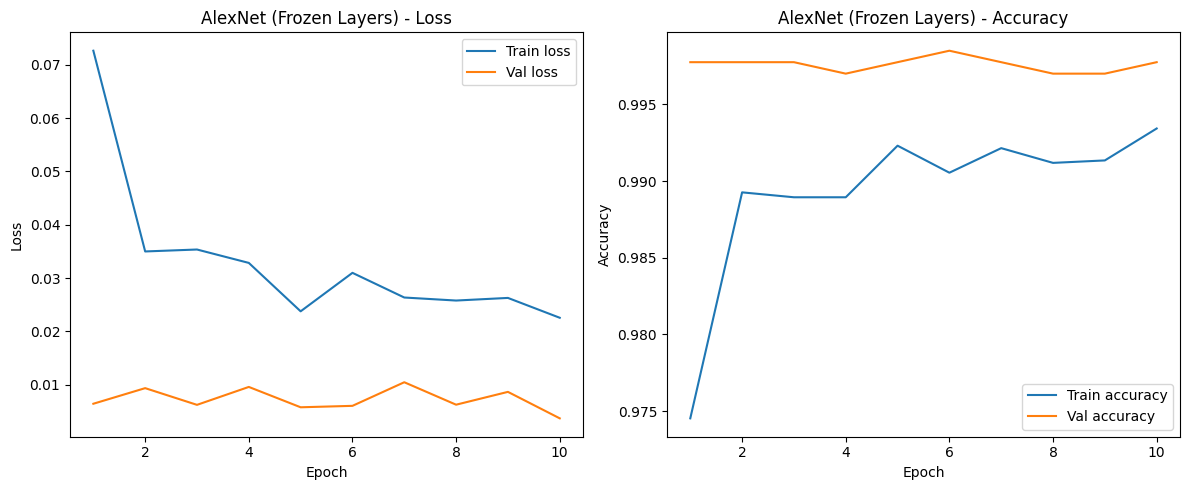

In [ ]:
plot_history(frozen_history, title="AlexNet (Frozen Layers)")

In [ ]:
frozen_metrics = evaluate_model(alexnet_frozen, test_loader, class_names)

print("=== AlexNet with frozen layers ===")
print(f"Accuracy: {frozen_metrics['accuracy']:.4f}")
print(f"Recall_macro: {frozen_metrics['recall_macro']:.4f}")
print(f"F1_macro: {frozen_metrics['f1_macro']:.4f}")
print("\nClassification report:\n")
print(frozen_metrics["report"])

=== AlexNet with frozen layers ===
Accuracy: 0.9970
Recall_macro: 0.9970
F1_macro: 0.9970

Classification report:

              precision    recall  f1-score   support

       anime       1.00      1.00      1.00       448
     cartoon       1.00      1.00      1.00       447
       human       1.00      1.00      1.00       444

    accuracy                           1.00      1339
   macro avg       1.00      1.00      1.00      1339
weighted avg       1.00      1.00      1.00      1339



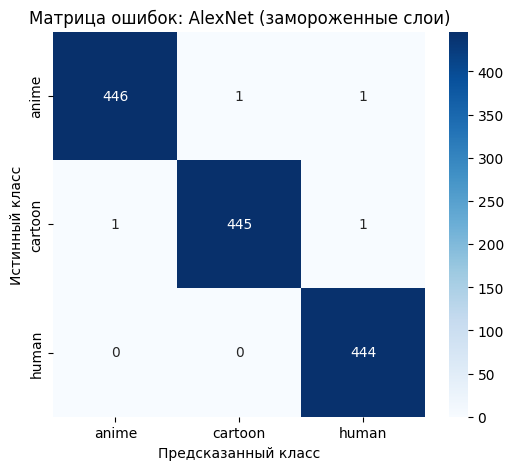

In [ ]:
plot_confusion_matrix(
    frozen_metrics["cm"],
    class_names,
    title="Матрица ошибок: AlexNet (замороженные слои)"
)

### Обучение 2: размороженные слои

In [ ]:
alexnet_unfrozen = create_alexnet_model(num_classes=num_classes, freeze_features=False)

alexnet_unfrozen, unfrozen_history = train_model(
    alexnet_unfrozen,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-5
)

Epoch 1/10
Train Loss: 0.1888 | Train Acc: 0.9306
Val   Loss: 0.0128 | Val   Acc: 0.9978
--------------------------------------------------
Epoch 2/10
Train Loss: 0.0286 | Train Acc: 0.9899
Val   Loss: 0.0066 | Val   Acc: 0.9985
--------------------------------------------------
Epoch 3/10
Train Loss: 0.0183 | Train Acc: 0.9939
Val   Loss: 0.0052 | Val   Acc: 0.9985
--------------------------------------------------
Epoch 4/10
Train Loss: 0.0218 | Train Acc: 0.9925
Val   Loss: 0.0053 | Val   Acc: 0.9985
--------------------------------------------------
Epoch 5/10
Train Loss: 0.0170 | Train Acc: 0.9947
Val   Loss: 0.0036 | Val   Acc: 0.9993
--------------------------------------------------
Epoch 6/10
Train Loss: 0.0146 | Train Acc: 0.9947
Val   Loss: 0.0041 | Val   Acc: 0.9985
--------------------------------------------------
Epoch 7/10
Train Loss: 0.0137 | Train Acc: 0.9954
Val   Loss: 0.0035 | Val   Acc: 0.9993
--------------------------------------------------
Epoch 8/10
Train Los

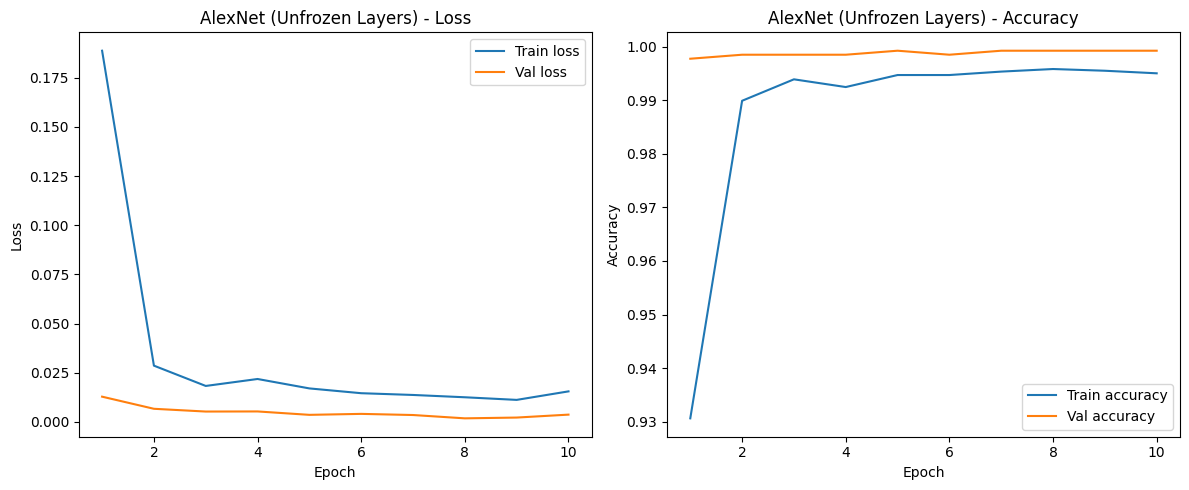

In [ ]:
plot_history(unfrozen_history, title="AlexNet (Unfrozen Layers)")

In [ ]:
unfrozen_metrics = evaluate_model(alexnet_unfrozen, test_loader, class_names)

print("=== AlexNet with unfrozen layers ===")
print(f"Accuracy: {unfrozen_metrics['accuracy']:.4f}")
print(f"Recall_macro: {unfrozen_metrics['recall_macro']:.4f}")
print(f"F1_macro: {unfrozen_metrics['f1_macro']:.4f}")
print("\nClassification report:\n")
print(unfrozen_metrics["report"])

=== AlexNet with unfrozen layers ===
Accuracy: 0.9993
Recall_macro: 0.9993
F1_macro: 0.9993

Classification report:

              precision    recall  f1-score   support

       anime       1.00      1.00      1.00       448
     cartoon       1.00      1.00      1.00       447
       human       1.00      1.00      1.00       444

    accuracy                           1.00      1339
   macro avg       1.00      1.00      1.00      1339
weighted avg       1.00      1.00      1.00      1339



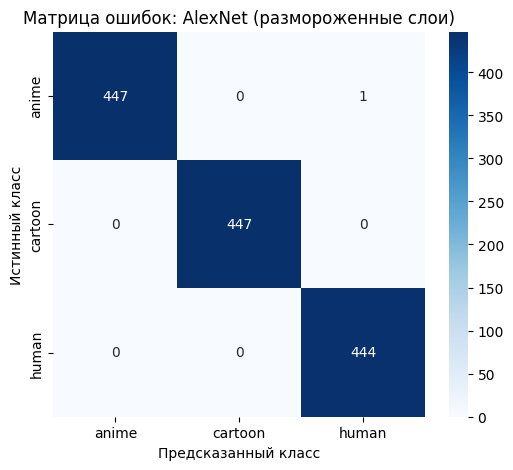

In [ ]:
plot_confusion_matrix(
    unfrozen_metrics["cm"],
    class_names,
    title="Матрица ошибок: AlexNet (размороженные слои)"
)

### Сравнение двух методов

In [ ]:
comparison = {
    "Frozen": {
        "Accuracy": frozen_metrics["accuracy"],
        "Recall_macro": frozen_metrics["recall_macro"],
        "F1_macro": frozen_metrics["f1_macro"]
    },
    "Unfrozen": {
        "Accuracy": unfrozen_metrics["accuracy"],
        "Recall_macro": unfrozen_metrics["recall_macro"],
        "F1_macro": unfrozen_metrics["f1_macro"]
    }
}

print(comparison)

{'Frozen': {'Accuracy': 0.9970126960418223, 'Recall_macro': 0.9970204804516886, 'F1_macro': 0.9970137970651664}, 'Unfrozen': {'Accuracy': 0.9992531740104555, 'Recall_macro': 0.9992559523809524, 'F1_macro': 0.9992526073905567}}


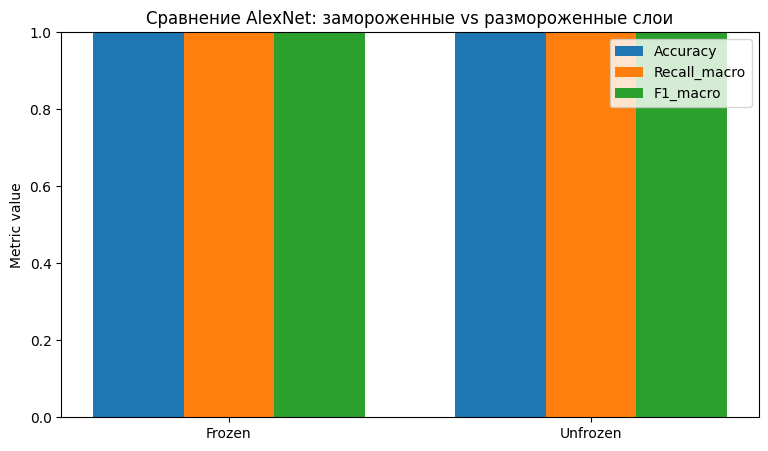

In [ ]:
methods = ["Frozen", "Unfrozen"]
acc_values = [comparison[m]["Accuracy"] for m in methods]
recall_values = [comparison[m]["Recall_macro"] for m in methods]
f1_values = [comparison[m]["F1_macro"] for m in methods]

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, acc_values, width, label="Accuracy")
plt.bar(x, recall_values, width, label="Recall_macro")
plt.bar(x + width, f1_values, width, label="F1_macro")

plt.xticks(x, methods)
plt.ylim(0, 1)
plt.ylabel("Metric value")
plt.title("Сравнение AlexNet: замороженные vs размороженные слои")
plt.legend()
plt.show()

### Полный вывод в таблицу

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Метод": ["Замороженные слои", "Размороженные слои"],
    "Accuracy": [frozen_metrics["accuracy"], unfrozen_metrics["accuracy"]],
    "Recall_macro": [frozen_metrics["recall_macro"], unfrozen_metrics["recall_macro"]],
    "F1_macro": [frozen_metrics["f1_macro"], unfrozen_metrics["f1_macro"]],
})

results_df

,Метод,Accuracy,Recall_macro,F1_macro
0,Замороженные слои,0.997013,0.997020,0.997014
1,Размороженные слои,0.999253,0.999256,0.999253
